# Visualizing US Natural Disaster Declarations: Trends and Patterns

## 1. Data Acquisition, Cleaning & Initial Exploration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load data
df = pd.read_csv('FEMA_Disaster_Declarations.csv')
print(f"Dataset shape: {df.shape}")
display(df.head())

Dataset shape: (69634, 28)


,femaDeclarationString,disasterNumber,state,declarationType,declarationDate,fyDeclared,incidentType,declarationTitle,ihProgramDeclared,iaProgramDeclared,...,placeCode,designatedArea,declarationRequestNumber,lastIAFilingDate,incidentId,region,designatedIncidentTypes,lastRefresh,hash,id
0,FM-5529-OR,5529,OR,FM,2024-08-09T00:00:00.000Z,2024,Fire,LEE FALLS FIRE,0,0,...,99067,Washington (County),24122,NaN,2024081001,10,R,2024-08-27T18:22:14.800Z,ae87cf3c6ed795015b714af7166c7c295b2b67c7,09e3f81a-5e16-4b72-b317-1c64e0cfa59c
1,FM-5528-OR,5528,OR,FM,2024-08-06T00:00:00.000Z,2024,Fire,ELK LANE FIRE,0,0,...,99031,Jefferson (County),24116,NaN,2024080701,10,R,2024-08-27T18:22:14.800Z,432cf0995c47e3895cea696ede5621b810460501,59983f89-30bf-4888-b21b-62e8d57d9aac
2,FM-5527-OR,5527,OR,FM,2024-08-02T00:00:00.000Z,2024,Fire,MILE MARKER 132 FIRE,0,0,...,99017,Deschutes (County),24111,NaN,2024080301,10,R,2024-08-27T18:22:14.800Z,2f21d90cb6bc64b0d4121aa3f18d852bbb4b11fa,8d13ecf0-bc2f-496b-8c9f-b2e73da832a0
3,DR-4312-CA,4312,CA,DR,2017-05-02T00:00:00.000Z,2017,Severe Storm,FLOODING,0,0,...,60347,Resighini Rancheria (Indian Reservation),17035,NaN,2017041001,9,NaN,2025-03-26T20:21:32.579Z,432a3a64bdbb291ae26cf5a27a33deeabb380481,98a7c5bb-2346-45aa-a1ca-0399440d4f0b
4,DR-4251-AL,4251,AL,DR,2016-01-21T00:00:00.000Z,2016,Severe Storm,"SEVERE STORMS, TORNADOES, STRAIGHT-LINE WINDS,...",0,0,...,99001,Autauga (County),16003,NaN,2015122301,4,NaN,2025-03-27T12:21:46.559Z,dcd4ce6b37ee49875b3f1e32e9a8a16cd6a803d3,5229bbae-eee6-42b8-b277-edbafa8d6cb2


In [3]:
# Data Cleaning
df['declarationDate'] = pd.to_datetime(df['declarationDate'])
df['incidentBeginDate'] = pd.to_datetime(df['incidentBeginDate'])
df['incidentEndDate'] = pd.to_datetime(df['incidentEndDate'])

df['declarationYear'] = df['declarationDate'].dt.year
df['declarationMonth'] = df['declarationDate'].dt.month
df['incidentDurationDays'] = (df['incidentEndDate'] - df['incidentBeginDate']).dt.days

# Standardize incident types
df['incidentType'] = df['incidentType'].str.title()
print("Missing values:")
print(df[['incidentBeginDate', 'incidentEndDate']].isnull().sum())

Missing values:
incidentBeginDate      0
incidentEndDate      833
dtype: int64


### Initial Exploratory Data Analysis (EDA)

c:\Users\ayush\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\ayush\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


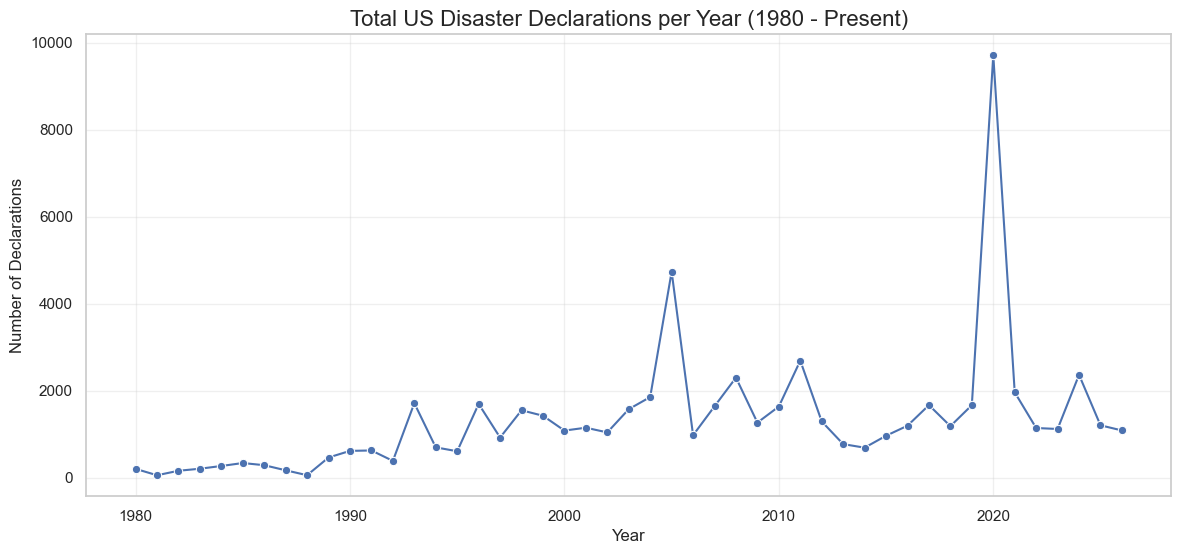

In [4]:
# Filter data from 1980 onwards for clearer recent trends
df_recent = df[df['declarationYear'] >= 1980]

# Plot declarations per year
plt.figure(figsize=(14, 6))
yearly_counts = df_recent.groupby('declarationYear').size()
sns.lineplot(x=yearly_counts.index, y=yearly_counts.values, marker='o', color='b')
plt.title('Total US Disaster Declarations per Year (1980 - Present)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Declarations', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

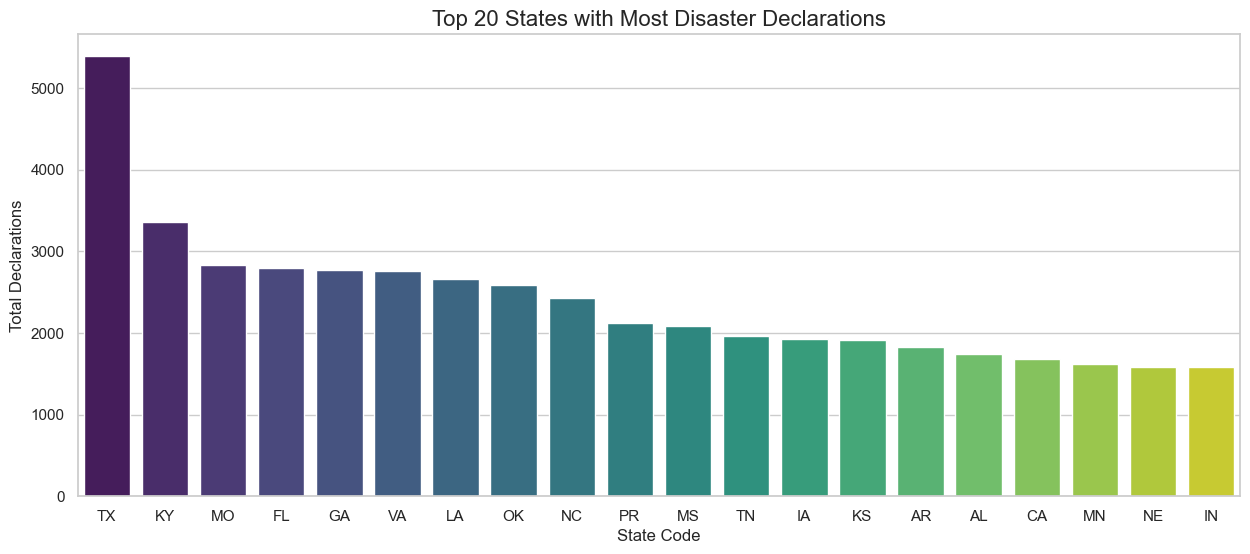

In [5]:
# Quick view of declarations per state
plt.figure(figsize=(15, 6))
state_counts = df['state'].value_counts().head(20)
sns.barplot(x=state_counts.index, y=state_counts.values, palette='viridis')
plt.title('Top 20 States with Most Disaster Declarations', fontsize=16)
plt.xlabel('State Code', fontsize=12)
plt.ylabel('Total Declarations', fontsize=12)
plt.show()

## 2. Temporal Trend Visualization

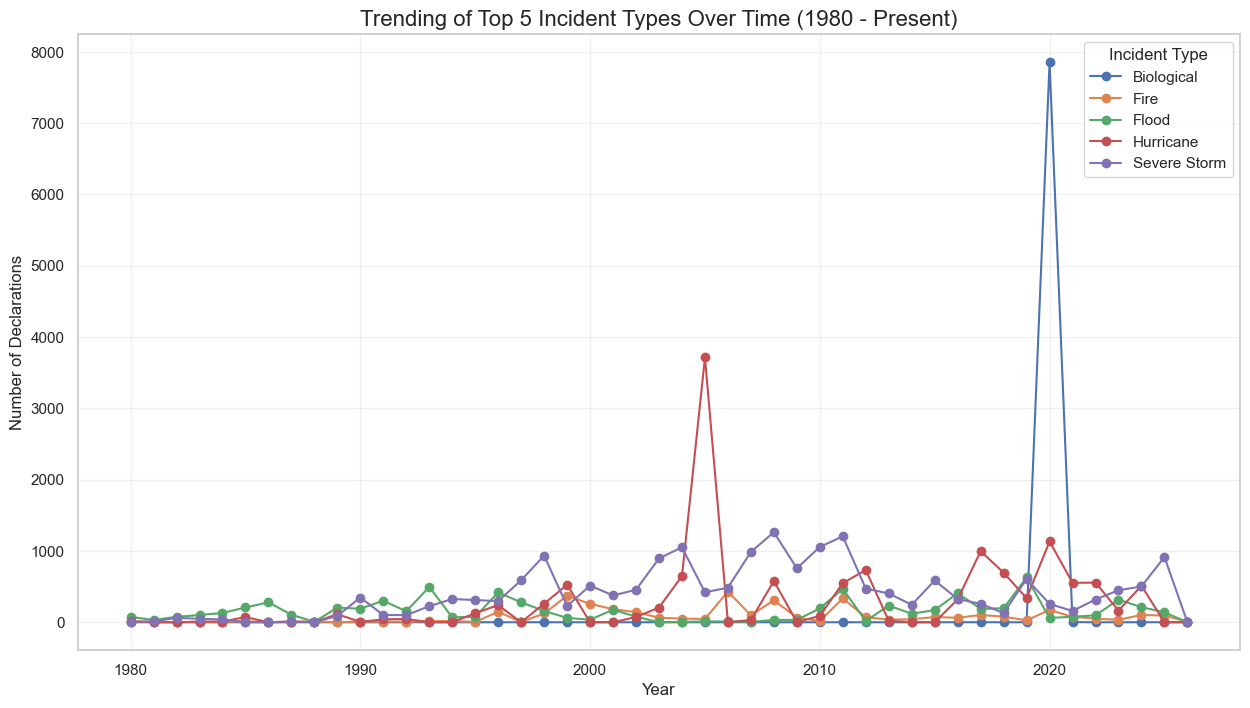

In [6]:
# Top 5 Incident Types over time
top_incidents = df['incidentType'].value_counts().head(5).index
df_top = df_recent[df_recent['incidentType'].isin(top_incidents)]

pivot_top = df_top.groupby(['declarationYear', 'incidentType']).size().unstack(fill_value=0)

pivot_top.plot(kind='line', figsize=(15, 8), marker='o')
plt.title('Trending of Top 5 Incident Types Over Time (1980 - Present)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Declarations', fontsize=12)
plt.legend(title='Incident Type')
plt.grid(True, alpha=0.3)
plt.show()

c:\Users\ayush\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


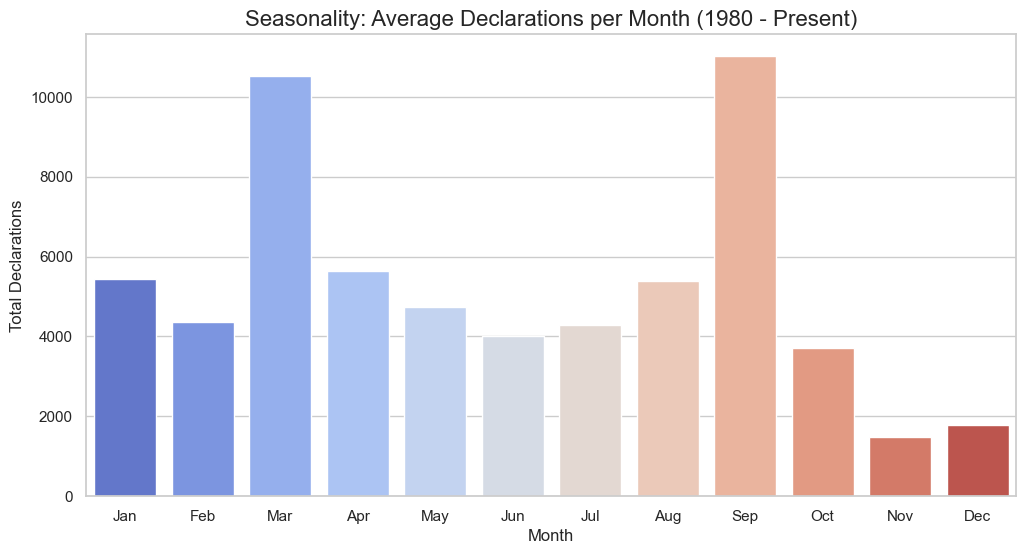

In [7]:
# Seasonality of Disasters
plt.figure(figsize=(12, 6))
monthly_counts = df_recent.groupby('declarationMonth').size()
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
sns.barplot(x=months, y=monthly_counts.values, palette='coolwarm')
plt.title('Seasonality: Average Declarations per Month (1980 - Present)', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Declarations', fontsize=12)
plt.show()

## 3. Geographical Pattern Visualization

In [8]:
# Choropleth Map using Plotly
state_totals = df['state'].value_counts().reset_index()
state_totals.columns = ['State', 'Total Declarations']

fig = px.choropleth(
    state_totals,
    locations='State',
    locationmode="USA-states",
    color='Total Declarations',
    color_continuous_scale="Reds",
    scope="usa",
    title="Total Natural Disaster Declarations by US State (1953 - Present)"
)
fig.show()

## 4. Incident Type Analysis & Synthesis

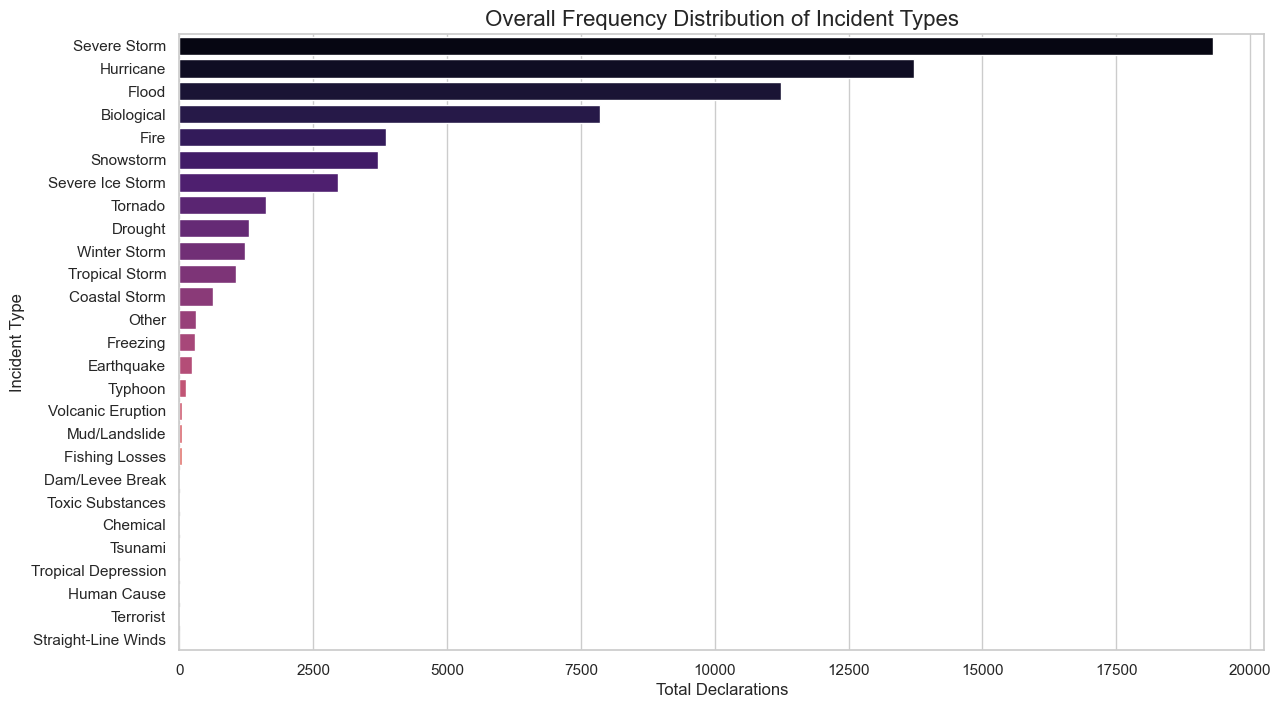

In [9]:
# Incident Types Distribution
plt.figure(figsize=(14, 8))
incident_counts = df['incidentType'].value_counts()
sns.barplot(y=incident_counts.index, x=incident_counts.values, palette='magma')
plt.title('Overall Frequency Distribution of Incident Types', fontsize=16)
plt.xlabel('Total Declarations', fontsize=12)
plt.ylabel('Incident Type', fontsize=12)
plt.show()

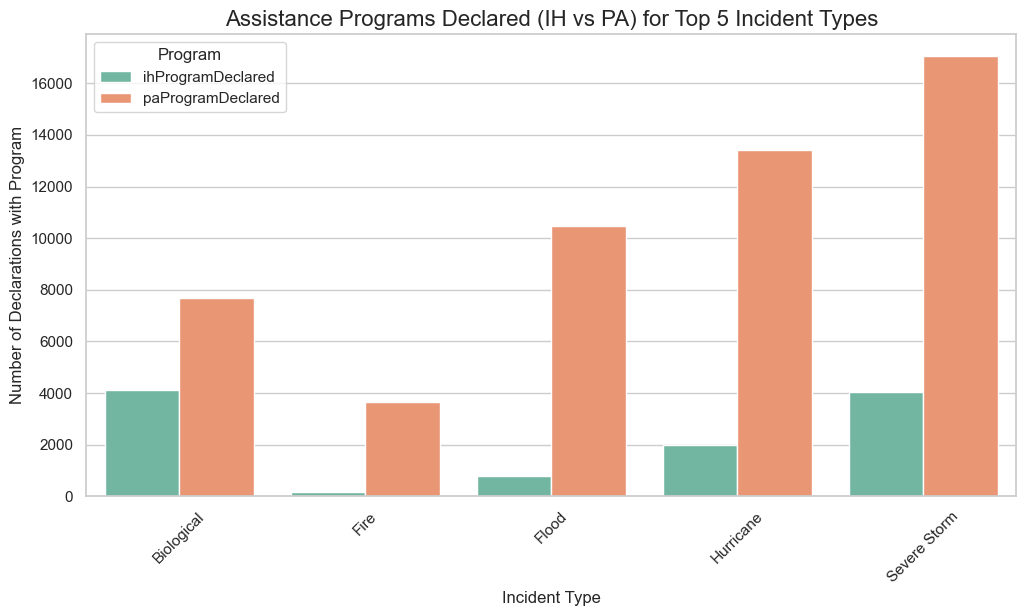

In [10]:
# Relationship between IncidentType and Assistance Programs
program_data = df.groupby('incidentType')[['ihProgramDeclared', 'paProgramDeclared']].sum().reset_index()
program_data = program_data.melt(id_vars='incidentType', var_name='Program', value_name='Count')
program_data = program_data[program_data['incidentType'].isin(top_incidents)] # Filter to top 5 for readability

plt.figure(figsize=(12, 6))
sns.barplot(data=program_data, x='incidentType', y='Count', hue='Program', palette='Set2')
plt.title('Assistance Programs Declared (IH vs PA) for Top 5 Incident Types', fontsize=16)
plt.xlabel('Incident Type', fontsize=12)
plt.ylabel('Number of Declarations with Program', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Program')
plt.show()